<div style="background:linear-gradient(135deg,#022c22 0%,#047857 55%,#10b981 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a7f3d0;font-weight:700;text-transform:uppercase">Chapter 137 &#183; Extended Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Difference-in-Differences</div>
  <div style="font-size:15px;color:#d1fae5;max-width:740px;line-height:1.6">Did a program actually work? A retailer launched a loyalty program in some stores and not others. We separate the program's real effect from the market-wide trend and the baseline gap between stores, the causal-inference workhorse when a clean experiment was not possible.</div>
  <div style="margin-top:16px;font-size:13px;color:#a7f3d0">Statistics, Data Science and AI: A Visual Handbook &#183; John Fisher &#183; 2026</div>
</div>

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 1 &#183; DEFINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The causal question, and why naive comparisons lie</div>
<div style="color:#4a5578;margin-top:6px">Correlation is easy; isolating a program's effect is the hard part.</div>
</div>

A retailer launched a **loyalty program** in 20 stores (the treated group) at month 13, leaving 20 similar stores untouched (the control group). Revenue per customer is up in the treated stores afterward, but so what: sales drift over time and the treated stores were already a little different. The question is causal: **how much of the lift did the program actually cause?** Two obvious comparisons each hide a bias, and **difference-in-differences (DiD)** removes both by comparing the treated group's before-to-after change against the control group's.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 2 &#183; DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A store-by-month panel</div>
<div style="color:#4a5578;margin-top:6px">Two groups, observed both before and after the launch.</div>
</div>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
EM="#059669"; DEEP="#047857"; LIGHT="#a7f3d0"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREY="#94a3b8"; BLUE="#2563eb"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_excel("../../data/ch137_loyalty_program.xlsx", sheet_name="Data")
except FileNotFoundError: df = pd.read_excel(BASE+"ch137_loyalty_program.xlsx", sheet_name="Data")
print(f"rows: {len(df)}  ({df.store.nunique()} stores x {df.month.nunique()} months)")
print(f"treated stores: {df[df.treated==1].store.nunique()}, control stores: {df[df.treated==0].store.nunique()}, launch at month 13")
df.head(4)

rows: 960  (40 stores x 24 months)
treated stores: 20, control stores: 20, launch at month 13


,store,group,treated,month,post,revenue_per_customer
0,T01,Treated,1,1,0,57.32
1,T01,Treated,1,2,0,54.77
2,T01,Treated,1,3,0,56.44
3,T01,Treated,1,4,0,58.96


<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 3 &#183; EXPLORE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Plot the two groups over time</div>
<div style="color:#4a5578;margin-top:6px">The single most important picture in a DiD study.</div>
</div>

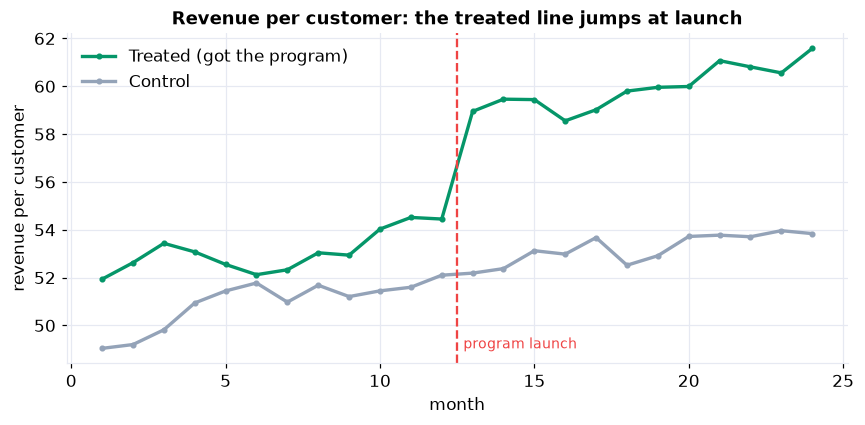

In [2]:
ts = df.groupby(["group","month"]).revenue_per_customer.mean().unstack(0)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(ts.index, ts["Treated"], color=EM, lw=2.2, marker="o", ms=3, label="Treated (got the program)")
ax.plot(ts.index, ts["Control"], color=GREY, lw=2.2, marker="o", ms=3, label="Control")
ax.axvline(12.5, color=RED, ls="--", lw=1.5); ax.text(12.7, ts.values.min(), "program launch", color=RED, fontsize=9)
ax.set(title="Revenue per customer: the treated line jumps at launch", xlabel="month", ylabel="revenue per customer"); ax.legend()
plt.tight_layout(); plt.show()

Two facts stand out. Before month 13 the lines run **parallel** (they move up together), and at the launch the **treated line steps up** and stays up while the control keeps drifting. The parallel pre-period is what makes the control a credible stand-in for what the treated stores would have done without the program.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 4 &#183; THE NAIVE TRAPS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two tempting comparisons, both biased</div>
<div style="color:#4a5578;margin-top:6px">Each naive number mixes the program's effect with something else.</div>
</div>

In [3]:
cell = df.groupby(["group","post"]).revenue_per_customer.mean().unstack()
print("average revenue per customer by group and period:")
print(cell.round(2).rename(columns={0:"pre",1:"post"}))
before_after = cell.loc["Treated",1] - cell.loc["Treated",0]   # treated only, before vs after
cross_section = cell.loc["Treated",1] - cell.loc["Control",1]  # post only, treated vs control
print(f"\nNAIVE before/after (treated only)   = {before_after:+.2f}  (but the whole market drifted up too)")
print(f"NAIVE treated-vs-control (post only) = {cross_section:+.2f}  (but treated stores started higher)")

average revenue per customer by group and period:
post       pre   post
group                
Control  50.93  53.23
Treated  53.08  59.93

NAIVE before/after (treated only)   = +6.85  (but the whole market drifted up too)
NAIVE treated-vs-control (post only) = +6.70  (but treated stores started higher)


The **before/after** number (+6.85) blames the program for a rise that partly reflects a **market-wide trend** every store enjoyed. The **treated-versus-control** number (+6.70) is inflated by the **baseline gap**: treated stores were already about 2 dollars ahead. Each comparison controls for one bias and ignores the other. DiD controls for both at once.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 5 &#183; PARALLEL TRENDS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The assumption that makes DiD credible</div>
<div style="color:#4a5578;margin-top:6px">Test what you can; reason about what you cannot.</div>
</div>

In [4]:
# DiD assumes that, without the program, treated and control would have moved in parallel.
# You cannot test that after launch, but you CAN test it BEFORE: is there a differential pre-trend?
pre = df[df.month < 13]
pt = smf.ols("revenue_per_customer ~ treated * month", pre).fit()
slope = pt.params["treated:month"]; pval = pt.pvalues["treated:month"]
print(f"differential PRE-trend (treated:month) = {slope:+.3f} per month,  p = {pval:.2f}")
print("-> not significant: the groups were NOT drifting apart before launch, so parallel trends is supported.")

differential PRE-trend (treated:month) = -0.063 per month,  p = 0.53
-> not significant: the groups were NOT drifting apart before launch, so parallel trends is supported.


The pre-period differential trend is a tiny **-0.06 per month (p = 0.53)**, statistically indistinguishable from zero: the two groups were not diverging before the program. That does not *prove* they would have stayed parallel afterward (the assumption is fundamentally untestable post-launch), but a clean pre-trend is the strongest evidence you can offer, and its absence would be a red flag that kills the design.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 6 &#183; THE 2x2</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Difference-in-differences, by hand</div>
<div style="color:#4a5578;margin-top:6px">Subtract twice, and the biases cancel.</div>
</div>

In [5]:
c_pre, c_post = cell.loc["Control",0], cell.loc["Control",1]
t_pre, t_post = cell.loc["Treated",0], cell.loc["Treated",1]
control_change = c_post - c_pre       # what happened WITHOUT the program (the counterfactual trend)
treated_change = t_post - t_pre       # what happened WITH it (trend + program)
did = treated_change - control_change # the program's effect, net of the common trend
print(f"control change (pre->post)  = {control_change:+.2f}   <- the market trend alone")
print(f"treated change (pre->post)  = {treated_change:+.2f}   <- trend + program")
print(f"DIFFERENCE-IN-DIFFERENCES   = {did:+.2f}   <- the program's causal effect")

control change (pre->post)  = +2.30   <- the market trend alone
treated change (pre->post)  = +6.85   <- trend + program
DIFFERENCE-IN-DIFFERENCES   = +4.55   <- the program's causal effect


The logic in one line: the control group's change (**+2.30**) is what the treated group *would* have done anyway, so subtracting it from the treated group's change (**+6.85**) leaves the program's effect, **+4.55 dollars** per customer. The baseline gap cancels in the first differences, and the common trend cancels in the second. That is the whole trick.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 7 &#183; DiD BY REGRESSION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The same answer, with inference attached</div>
<div style="color:#4a5578;margin-top:6px">One interaction coefficient is the causal estimate.</div>
</div>

In [6]:
# revenue ~ treated + post + treated:post.  The interaction IS the DiD estimate.
m = smf.ols("revenue_per_customer ~ treated + post + treated:post", df).fit()
print(m.params.round(3).to_string())
print(f"\ntreated:post (the DiD estimate) = {m.params['treated:post']:.3f}   (matches the 2x2 table)")
print("reading the coefficients:")
print("  Intercept    = control, pre  (baseline)")
print("  treated      = the baseline gap between groups")
print("  post         = the common market trend")
print("  treated:post = the program effect, on top of both")

Intercept       50.934
treated          2.151
post             2.296
treated:post     4.550

treated:post (the DiD estimate) = 4.550   (matches the 2x2 table)
reading the coefficients:
  Intercept    = control, pre  (baseline)
  treated      = the baseline gap between groups
  post         = the common market trend
  treated:post = the program effect, on top of both


The regression reproduces the 2x2 exactly, but now every piece of the story is a **coefficient**: the intercept is the control baseline, `treated` is the group gap, `post` is the market trend, and the **interaction `treated:post` is the causal effect**. Writing DiD as a regression is what lets us add standard errors, control variables, and more than two periods.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 8 &#183; UNCERTAINTY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A standard error that respects the panel</div>
<div style="color:#4a5578;margin-top:6px">Observations from the same store are not independent.</div>
</div>

In [7]:
# Repeated months from one store are correlated, so we CLUSTER the standard errors by store.
mc = smf.ols("revenue_per_customer ~ treated + post + treated:post", df).fit(cov_type="cluster", cov_kwds={"groups": df["store"]})
est = mc.params["treated:post"]; lo, hi = mc.conf_int().loc["treated:post"]
print(f"DiD estimate = {est:.2f}   95% clustered CI [{lo:.2f}, {hi:.2f}]   p = {mc.pvalues['treated:post']:.1e}")
print(f"the true program effect (we know it here) = +4.00, comfortably inside the interval")

DiD estimate = 4.55   95% clustered CI [3.33, 5.77]   p = 2.7e-13
the true program effect (we know it here) = +4.00, comfortably inside the interval


Clustering by store widens the interval honestly to account for the fact that a store's 24 months are not 24 independent data points. The program lifted revenue per customer by **4.55 dollars, 95% CI [3.33, 5.77]**, and that interval contains the true effect of 4.00. Never report a panel DiD with plain standard errors; cluster at the level treatment was assigned.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 9 &#183; ROBUSTNESS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A placebo test</div>
<div style="color:#4a5578;margin-top:6px">If the method finds an effect where none exists, do not trust it.</div>
</div>

In [8]:
# Placebo: pretend the launch happened at month 7, using ONLY the pre-launch data (months 1-12).
# There was no program then, so an honest DiD should find nothing.
fake = df[df.month < 13].copy()
fake["fake_post"] = (fake["month"] >= 7).astype(int)
pm = smf.ols("revenue_per_customer ~ treated + fake_post + treated:fake_post", fake).fit(cov_type="cluster", cov_kwds={"groups": fake["store"]})
print(f"placebo DiD (fake launch, pre-period only) = {pm.params['treated:fake_post']:+.2f}   p = {pm.pvalues['treated:fake_post']:.2f}")
print("-> near zero and not significant: the method does NOT manufacture effects, so the real +4.55 is credible.")

placebo DiD (fake launch, pre-period only) = -0.20   p = 0.73
-> near zero and not significant: the method does NOT manufacture effects, so the real +4.55 is credible.


The placebo finds essentially **nothing** (a small, non-significant estimate), exactly what should happen when no program existed. A placebo that lit up would mean the design was picking up spurious differences rather than a real effect. Passing it is a key credibility check.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 10 &#183; INTERPRET</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What the estimate means</div>
<div style="color:#4a5578;margin-top:6px">From a coefficient to a business number.</div>
</div>

The loyalty program **caused** revenue per customer to rise by about **4.55 dollars** (95% CI 3.33 to 5.77), net of the market-wide trend and the pre-existing gap between the store groups. On the treated stores' base of roughly 53 dollars, that is a **9% lift** attributable to the program, not to the calendar and not to the stores being different to begin with. The naive before/after number would have credited the program with 6.85 dollars, overstating its impact by about half.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 11 &#183; CAVEATS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What could still break this</div>
<div style="color:#4a5578;margin-top:6px">Every causal claim rests on assumptions worth stating.</div>
</div>

Three honest caveats. **Parallel trends** is the load-bearing assumption; the clean pre-trend supports it but cannot guarantee it held after launch (something else could have hit the treated stores at month 13). **No spillovers**: if treated stores drew customers from nearby control stores, the control is contaminated and the effect is overstated. **Composition**: the stores must be stable over the window; a treated store closing or a big remodel would confound the comparison. A good analysis names these and, where possible, checks them (the Take It Further notebook adds an event study and covariates).

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 12 &#183; COMMUNICATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One paragraph for the leadership team</div>
<div style="color:#4a5578;margin-top:6px">Plain English, decision-ready.</div>
</div>

**For leadership:** The loyalty program raised revenue per customer by an estimated **4.55 dollars (about 9%)** in the stores that received it, a clear and statistically strong effect (95% confidence interval 3.33 to 5.77). We reach that number with a difference-in-differences comparison against 20 matched control stores, which strips out the market-wide sales trend and the pre-existing differences between stores, biases that make a simple before-and-after look 50% larger than the truth. The two groups moved in parallel before launch and a placebo test found no spurious effect, so we are confident the lift is caused by the program. We recommend rolling it out to the remaining stores and re-checking the effect once new data arrives.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook &#183; &#169; 2026 John Fisher</div>